Batch vs Mini-batch vs Stochastic Gradient Descent
Porównaj trzy warianty Gradient Descent na tym samym zbiorze danych.
Dataset: X, y = make_regression(n_samples=1000, n_features=1, noise=30)

Wymagania:
Zaimplementuj wszystkie 3 warianty
Zmierz czas wykonania
Porównaj krzywe uczenia
Określ, który wariant jest najefektywniejszy

Oczekiwany rezultat:
Tabela porównawcza (czas, końcowy loss, liczba iteracji)
Wykres krzywych uczenia

=== Porównanie ===
         method    time_s  final_loss  n_iterations
0       BatchGD  0.024881  882.275524           200
1   MiniBatchGD  0.205401  882.167040           200
2  StochasticGD  4.270413  882.203927           200


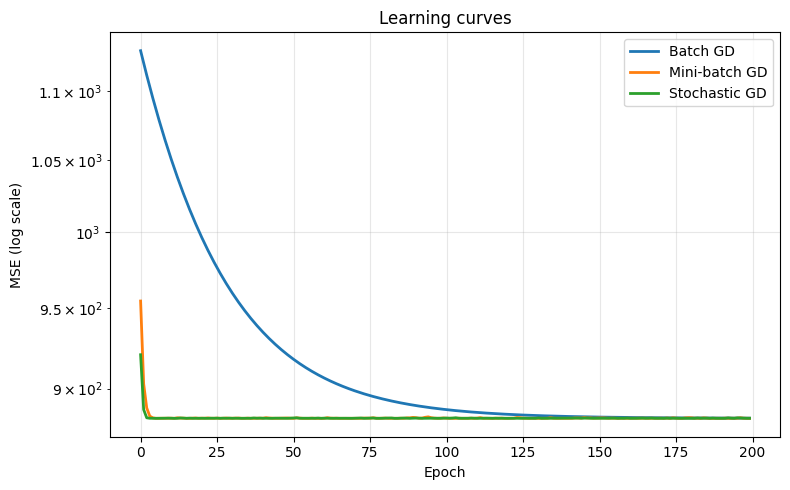

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.metrics import mean_squared_error

# ---- Dane ----
np.random.seed(42)
X, y = make_regression(n_samples=1000, n_features=1, noise=30, random_state=42)
X = X.reshape(-1, 1)
y = y.reshape(-1, 1)

# Dodaj bias (kolumna 1) do X dla modelu liniowego: y = X_w * w
X_b = np.hstack([np.ones((X.shape[0], 1)), X])  # shape (n,2)

# Funkcja pomocnicza: loss MSE i gradient
def mse_loss(y_true, y_pred):
    return float(((y_true - y_pred) ** 2).mean())

# ---- Warianty GD ----
def batch_gd(X, y, lr=0.01, epochs=200):
    n, d = X.shape
    w = np.zeros((d, 1))
    losses = []
    start = time.time()
    for epoch in range(epochs):
        preds = X.dot(w)
        grad = (2 / n) * X.T.dot(preds - y)
        w -= lr * grad
        losses.append(mse_loss(y, X.dot(w)))
    elapsed = time.time() - start
    return w, losses, elapsed

def mini_batch_gd(X, y, lr=0.01, epochs=50, batch_size=32):
    n, d = X.shape
    w = np.zeros((d, 1))
    losses = []
    start = time.time()
    for epoch in range(epochs):
        perm = np.random.permutation(n)
        X_sh, y_sh = X[perm], y[perm]
        for i in range(0, n, batch_size):
            xb = X_sh[i:i+batch_size]
            yb = y_sh[i:i+batch_size]
            grad = (2 / xb.shape[0]) * xb.T.dot(xb.dot(w) - yb)
            w -= lr * grad
        losses.append(mse_loss(y, X.dot(w)))
    elapsed = time.time() - start
    return w, losses, elapsed

def stochastic_gd(X, y, lr=0.001, epochs=10):
    n, d = X.shape
    w = np.zeros((d, 1))
    losses = []
    start = time.time()
    for epoch in range(epochs):
        perm = np.random.permutation(n)
        X_sh, y_sh = X[perm], y[perm]
        for i in range(n):
            xi = X_sh[i:i+1]
            yi = y_sh[i:i+1]
            grad = 2 * xi.T.dot(xi.dot(w) - yi)  # /1 omitted
            w -= lr * grad
        losses.append(mse_loss(y, X.dot(w)))
    elapsed = time.time() - start
    return w, losses, elapsed

# ---- Uruchomienia z dobranymi hiperparametrami ----
# Dostosowałem lr/epochs tak, żeby porównanie było sensowne i konwergowało.
w_b, loss_b, t_b = batch_gd(X_b, y, lr=0.01, epochs=200)
w_m, loss_m, t_m = mini_batch_gd(X_b, y, lr=0.01, epochs=200, batch_size=32)
w_s, loss_s, t_s = stochastic_gd(X_b, y, lr=0.0005, epochs=200)  # mniejsze lr, więcej epok

# ---- Wyniki końcowe ----
final_loss_b = loss_b[-1]
final_loss_m = loss_m[-1]
final_loss_s = loss_s[-1]

print("=== Porównanie ===")
results = pd.DataFrame({
    'method': ['BatchGD', 'MiniBatchGD', 'StochasticGD'],
    'time_s': [t_b, t_m, t_s],
    'final_loss': [final_loss_b, final_loss_m, final_loss_s],
    'n_iterations': [len(loss_b), len(loss_m), len(loss_s)]
})
print(results)

# ---- Wykres krzywych uczenia ----
plt.figure(figsize=(8,5))
plt.plot(np.arange(len(loss_b)), loss_b, label='Batch GD', lw=2)
plt.plot(np.arange(len(loss_m)), loss_m, label='Mini-batch GD', lw=2)
plt.plot(np.arange(len(loss_s)), loss_s, label='Stochastic GD', lw=2)
plt.yscale('log')  # log scale by lepiej widzieć konwergencję
plt.xlabel('Epoch')
plt.ylabel('MSE (log scale)')
plt.title('Learning curves')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Learning Curves Analysis
Przeanalizuj learning curves dla modelu.
Dataset: California Housing

Oczekiwany rezultat:
    Wygeneruj learning curves dla SGDRegressor  
    Zidentyfikuj, czy model ma underfitting/overfitting
    Zaproponuj rozwiązanie

Wymagania:
Wykres learning curves
Diagnoza i rekomendacje

Train RMSE (last): 8.615777543641698
Val RMSE (last): 7.209572032399235


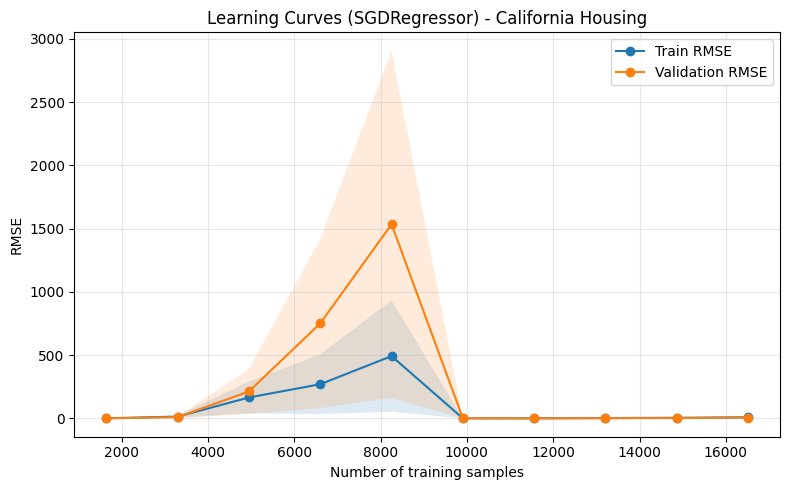

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import learning_curve
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, mean_squared_error

# dane
data = fetch_california_housing(as_frame=True)
X = data.data
y = data.target

# model pipeline
model = make_pipeline(StandardScaler(),
                      SGDRegressor(max_iter=5000, tol=1e-4, random_state=42))

# scorer (sklearn expects "większe lepsze" → używamy negatywnego MSE)
neg_mse_scorer = make_scorer(mean_squared_error, greater_is_better=False)

# learning curve
train_sizes = np.linspace(0.1, 1.0, 10)
train_sizes_abs, train_scores, val_scores = learning_curve(
    model, X, y,
    train_sizes=train_sizes,
    cv=5,
    scoring=neg_mse_scorer,
    shuffle=True,
    random_state=42,
    n_jobs=-1
)

# przetworzenie wyników na RMSE
train_mse = -train_scores    # shape (n_sizes, n_folds)
val_mse = -val_scores
train_rmse_mean = np.sqrt(train_mse.mean(axis=1))
train_rmse_std = np.sqrt(train_mse).std(axis=1)
val_rmse_mean = np.sqrt(val_mse.mean(axis=1))
val_rmse_std = np.sqrt(val_mse).std(axis=1)

# wydruk podstawowych wartości (ostatni punkt = pełny zestaw)
print("Train RMSE (last):", train_rmse_mean[-1])
print("Val RMSE (last):", val_rmse_mean[-1])

# wykres
plt.figure(figsize=(8,5))
plt.plot(train_sizes_abs, train_rmse_mean, 'o-', label='Train RMSE')
plt.fill_between(train_sizes_abs,
                 train_rmse_mean - train_rmse_std,
                 train_rmse_mean + train_rmse_std,
                 alpha=0.15)
plt.plot(train_sizes_abs, val_rmse_mean, 'o-', label='Validation RMSE')
plt.fill_between(train_sizes_abs,
                 val_rmse_mean - val_rmse_std,
                 val_rmse_mean + val_rmse_std,
                 alpha=0.15)
plt.xlabel('Number of training samples')
plt.ylabel('RMSE')
plt.title('Learning Curves (SGDRegressor) - California Housing')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
